# In-situ SM skill from raw_timeseries (MATLAB cache)

This notebook mirrors `SMskill_vs_INSITU_single_CYG_expt.m` **after** the raw time series are cached.
It reads the `*_raw_timeseries.mat` files and computes the same statistics (R, anomR, Bias, RMSE, ubRMSE
+ CI) using the Python ported functions.

Notes:
- This assumes the MAT file contains `LDAS_sm_org`, `INSITU_sm`, and `date_time_vec` (MATLAB struct array).
- If your MAT file is v7.3 (HDF5), scipy may fail; see the loader cell for fallbacks.


In [1]:
from pathlib import Path
import sys
import numpy as np
import scipy.io as sio
import xarray as xr

# ---- paths ----
RAW_MAT_FILES = [
    Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat"),
    Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_DAv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat"),
]

OUT_DIR = Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2")
INSITU_TAG = "SCAN"
FILE_TAG = "ldas_tile_daily_out"
ADD_ANOMR = True

# ---- import stats helpers from existing script ----
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT / "projects/matlab2python/scripts"))

from sm_skill_vs_insitu import get_validation_stats, compute_anom  # type: ignore


In [2]:
# ---- MAT loader helpers ----


def load_mat_file(path: Path):
    # Load MATLAB MAT file. Tries scipy (v5/v7), falls back to h5py for v7.3.
    try:
        return sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    except NotImplementedError as e:
        # Likely v7.3
        try:
            import h5py
        except Exception as e2:
            raise RuntimeError(
                f"MAT file appears to be v7.3 (HDF5) but h5py is not available: {e2}"
            ) from e
        with h5py.File(path, "r") as f:
            # Shallow read: expose top-level keys for manual mapping
            return {k: f[k] for k in f.keys()}



def mat_struct_to_array(ms, field):
    # Extract a field from a MATLAB struct array loaded with scipy (struct_as_record=False).
    if isinstance(ms, np.ndarray):
        flat = ms.ravel()
        return np.array([getattr(x, field) for x in flat])
    return np.array([getattr(ms, field)])



def summarize_mat(mat):
    keys = [k for k in mat.keys() if not k.startswith("__")]
    print("Keys:", keys)
    for k in keys:
        v = mat[k]
        if hasattr(v, "shape"):
            print(f"  {k}: shape={v.shape}, dtype={getattr(v, 'dtype', None)}")
        else:
            print(f"  {k}: type={type(v)}")


In [3]:
# ---- core computation ----


def compute_stats_from_raw(mat, file_tag: str, insitu_tag: str, add_anomR: bool = True):
    # Required arrays
    if "LDAS_sm_org" not in mat or "INSITU_sm" not in mat or "date_time_vec" not in mat:
        raise KeyError("MAT file must contain LDAS_sm_org, INSITU_sm, and date_time_vec")

    ldas_sm_org = mat["LDAS_sm_org"]
    insitu_sm = mat["INSITU_sm"]
    dt_vec = mat["date_time_vec"]

    # Normalize dimensions: LDAS_sm_org expected (time, depth, site[, exp])
    if ldas_sm_org.ndim == 4:
        ldas_sm_org = ldas_sm_org[:, :, :, 0]
    if ldas_sm_org.ndim != 3:
        raise ValueError(f"Unexpected LDAS_sm_org shape {ldas_sm_org.shape}")

    # INSITU_sm expected (time, depth, site)
    if insitu_sm.ndim != 3:
        raise ValueError(f"Unexpected INSITU_sm shape {insitu_sm.shape}")

    # Build doy vector from date_time_vec.dofyr if present
    if hasattr(dt_vec, "dtype") or isinstance(dt_vec, np.ndarray):
        try:
            doy_vec = mat_struct_to_array(dt_vec, "dofyr").astype(int).ravel()
        except Exception:
            # fallback: try year/month/day and compute doy
            year = mat_struct_to_array(dt_vec, "year").astype(int).ravel()
            month = mat_struct_to_array(dt_vec, "month").astype(int).ravel()
            day = mat_struct_to_array(dt_vec, "day").astype(int).ravel()
            import datetime as _dt
            doy_vec = np.array([_dt.date(int(y), int(m), int(d)).timetuple().tm_yday for y, m, d in zip(year, month, day)])
    else:
        raise ValueError("date_time_vec is not a scipy MATLAB struct array; inspect manually")

    # Nmin like MATLAB
    Nmin = 200 if "daily" in file_tag else 480
    Nmin_day = 60

    # Cross-mask model/obs
    ldas_sm = np.copy(ldas_sm_org[:, :2, :])
    ldas_sm[ldas_sm == 0] = np.nan
    ldas_sm[np.isnan(insitu_sm)] = np.nan
    insitu_sm = np.where(np.isnan(ldas_sm), np.nan, insitu_sm)

    n_time, n_depth, n_site = ldas_sm.shape

    # Allocate
    stats_R = np.full((n_site, n_depth), np.nan)
    stats_RLO = np.full((n_site, n_depth), np.nan)
    stats_RUP = np.full((n_site, n_depth), np.nan)
    stats_bias = np.full((n_site, n_depth), np.nan)
    stats_biasCI = np.full((n_site, n_depth), np.nan)
    stats_rmse = np.full((n_site, n_depth), np.nan)
    stats_rmseCI = np.full((n_site, n_depth), np.nan)
    stats_ubrmse = np.full((n_site, n_depth), np.nan)
    stats_ubrmseCI = np.full((n_site, n_depth), np.nan)
    stats_anomR = np.full((n_site, n_depth), np.nan) if add_anomR else None
    stats_anomRLO = np.full((n_site, n_depth), np.nan) if add_anomR else None
    stats_anomRUP = np.full((n_site, n_depth), np.nan) if add_anomR else None

    for i_site in range(n_site):
        for j_depth in range(n_depth):
            tmp = np.column_stack([insitu_sm[:, j_depth, i_site], ldas_sm[:, j_depth, i_site]])
            s = get_validation_stats(tmp, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=Nmin)
            stats_R[i_site, j_depth] = s["R"]
            stats_RLO[i_site, j_depth] = s["RLO"]
            stats_RUP[i_site, j_depth] = s["RUP"]
            stats_bias[i_site, j_depth] = s["bias"]
            stats_biasCI[i_site, j_depth] = s["CI_bias"]
            rmse = np.sqrt(s["MSE"]) if not np.isnan(s["MSE"]) else np.nan
            stats_rmse[i_site, j_depth] = rmse
            stats_rmseCI[i_site, j_depth] = np.sqrt(max(s["CI_MSE"] + s["MSE"], 0)) - rmse if not np.isnan(s["CI_MSE"]) else np.nan
            ubmse = s["ubMSE"]
            stats_ubrmse[i_site, j_depth] = np.sqrt(ubmse) if not np.isnan(ubmse) else np.nan
            if not np.isnan(s["ubMSELO"]):
                stats_ubrmseCI[i_site, j_depth] = np.sqrt(max(ubmse + s["ubMSEUP"], 0)) - stats_ubrmse[i_site, j_depth]
            if add_anomR:
                obs_anom = compute_anom(tmp[:, 0], doy_vec, Nmin_day=Nmin_day)
                mod_anom = compute_anom(tmp[:, 1], doy_vec, Nmin_day=Nmin_day)
                tmp_anom = np.column_stack([obs_anom, mod_anom])
                sa = get_validation_stats(tmp_anom, AC=True, complete=True, ref_col=1, select_cols=[1, 2], Nmin=Nmin)
                stats_anomR[i_site, j_depth] = sa["R"]
                stats_anomRLO[i_site, j_depth] = sa["RLO"]
                stats_anomRUP[i_site, j_depth] = sa["RUP"]

    return {
        "R": stats_R,
        "RLO": stats_RLO,
        "RUP": stats_RUP,
        "Bias": stats_bias,
        "BiasCI": stats_biasCI,
        "RMSE": stats_rmse,
        "RMSECI": stats_rmseCI,
        "ubRMSE": stats_ubrmse,
        "ubRMSECI": stats_ubrmseCI,
        "anomR": stats_anomR,
        "anomRLO": stats_anomRLO,
        "anomRUP": stats_anomRUP,
        "Nmin": Nmin,
    }


In [4]:
# ---- run for each raw_timeseries file ----

OUT_DIR.mkdir(parents=True, exist_ok=True)

results = {}
meta = {}

for raw_path in RAW_MAT_FILES:
    print(f"Loading {raw_path} ...")
    mat = load_mat_file(raw_path)
    summarize_mat(mat)

    stats = compute_stats_from_raw(mat, FILE_TAG, INSITU_TAG, add_anomR=ADD_ANOMR)

    # Optional metadata if present
    ids = None
    lat = None
    lon = None
    if "INSITU_id" in mat:
        ids = [str(x) for x in np.ravel(mat["INSITU_id"])]
    if "INSITU_lat" in mat:
        lat = np.ravel(mat["INSITU_lat"]).astype(float)
    if "INSITU_lon" in mat:
        lon = np.ravel(mat["INSITU_lon"]).astype(float)

    exp_key = raw_path.name.replace("_raw_timeseries.mat", "")
    results[exp_key] = dict(stats=stats, ids=ids, lat=lat, lon=lon)
    if not meta and ids is not None and lat is not None and lon is not None:
        meta = dict(ids=ids, lat=lat, lon=lon)

    n_site, n_depth = stats["R"].shape
    ds = xr.Dataset(
        data_vars={
            "R": (("site", "depth"), stats["R"]),
            "RLO": (("site", "depth"), stats["RLO"]),
            "RUP": (("site", "depth"), stats["RUP"]),
            "Bias": (("site", "depth"), stats["Bias"]),
            "BiasCI": (("site", "depth"), stats["BiasCI"]),
            "RMSE": (("site", "depth"), stats["RMSE"]),
            "RMSECI": (("site", "depth"), stats["RMSECI"]),
            "ubRMSE": (("site", "depth"), stats["ubRMSE"]),
            "ubRMSECI": (("site", "depth"), stats["ubRMSECI"]),
        },
        coords=dict(
            site=np.arange(n_site),
            depth=np.arange(n_depth),
        ),
        attrs=dict(
            insitu_tag=INSITU_TAG,
            file_tag=FILE_TAG,
            Nmin=int(stats["Nmin"]),
            add_anomR=int(ADD_ANOMR),
            source_raw=str(raw_path),
        ),
    )

    if ADD_ANOMR:
        ds["anomR"] = (("site", "depth"), stats["anomR"])
        ds["anomRLO"] = (("site", "depth"), stats["anomRLO"])
        ds["anomRUP"] = (("site", "depth"), stats["anomRUP"])

    if ids is not None:
        ds = ds.assign_coords(site_id=("site", ids))
    if lat is not None:
        ds = ds.assign_coords(site_lat=("site", lat))
    if lon is not None:
        ds = ds.assign_coords(site_lon=("site", lon))

    base = raw_path.name.replace("_raw_timeseries.mat", "_stats")
    out_nc = OUT_DIR / f"{base}.nc"
    out_npz = OUT_DIR / f"{base}.npz"

    ds.to_netcdf(out_nc)
    np.savez_compressed(out_npz, **{k: v for k, v in stats.items() if k not in ["Nmin"]})

    print(f"Wrote {out_nc}")
    print(f"Wrote {out_npz}")


Loading /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_SCAN_SM_1d_c1234smv_25yr_raw_timeseries.mat ...
Keys: ['INSITU_id', 'INSITU_id_string', 'INSITU_lat', 'INSITU_lon', 'INSITU_path', 'INSITU_sm', 'INSITU_st', 'INSITU_tag', 'LDAS_prcp_org', 'LDAS_sm_org', 'LDAS_st_org', 'Nmin', 'add_anomR', 'data_ext', 'date_time', 'date_time_string', 'date_time_vec', 'date_time_vec1', 'distance', 'distance_min', 'domain', 'dtstep', 'end_time', 'exp_path', 'exp_run', 'exp_run_name', 'file_ext', 'file_tag', 'fname', 'fname_tilecoord', 'fname_tmp', 'fout_name', 'fout_path', 'i', 'ind_hour', 'ind_tile', 'ind_tmp', 'j', 'k', 'kkk', 'max_distance', 'out_collection', 'ref_T', 'ref_YMD', 'rzmc_tag', 'start_time', 't_ind', 'tavg_tag_INSITU', 'tc', 'this_lat', 'this_lon', 'tile_coord', 'tmpstr', 'w_mat_tmp', 'w_mat_tmp3d', 'w_tmp']
  INSITU_id: shape=(146,), dtype=object
  INSITU_id_string: type=<class 'str'>
  INSITU_lat: shape=(146,), dtype=float64
  INSITU_lon: shape=(

In [5]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False


In [6]:
# ---- aggregate stats for plotting ----

if not results:
    raise RuntimeError("No results found. Run the previous cell first.")

exp_keys = list(results.keys())
exp_labels = [k.replace("LS_", "").replace("_M36", "") for k in exp_keys]

R = np.stack([results[k]["stats"]["R"] for k in exp_keys], axis=2)
RLO = np.stack([results[k]["stats"]["RLO"] for k in exp_keys], axis=2)
RUP = np.stack([results[k]["stats"]["RUP"] for k in exp_keys], axis=2)
ubRMSE = np.stack([results[k]["stats"]["ubRMSE"] for k in exp_keys], axis=2)

anomR = None
anomRLO = None
anomRUP = None
if ADD_ANOMR:
    anomR = np.stack([results[k]["stats"]["anomR"] for k in exp_keys], axis=2)
    anomRLO = np.stack([results[k]["stats"]["anomRLO"] for k in exp_keys], axis=2)
    anomRUP = np.stack([results[k]["stats"]["anomRUP"] for k in exp_keys], axis=2)

num_sites_r = np.sum(~np.isnan(R), axis=0)
R_mean = np.nanmean(R, axis=0)
R_CI = np.array([
    -np.nanmean(RLO, axis=0) / np.sqrt(num_sites_r),
    np.nanmean(RUP, axis=0) / np.sqrt(num_sites_r),
])

num_sites_ubrmse = np.sum(~np.isnan(ubRMSE), axis=0)
ubRMSE_mean = np.nanmean(ubRMSE, axis=0)

# If ubRMSECI is present (single-sided), use it symmetrically
try:
    ub_ci = np.stack([results[k]["stats"]["ubRMSECI"] for k in exp_keys], axis=2)
    ub_ci_mean = np.abs(np.nanmean(ub_ci, axis=0) / np.sqrt(num_sites_ubrmse))
    ubRMSE_CI = np.array([ub_ci_mean, ub_ci_mean])
except Exception:
    ubRMSE_CI = np.zeros((2,) + ubRMSE_mean.shape)

if anomR is not None:
    num_sites_anomr = np.sum(~np.isnan(anomR), axis=0)
    anomR_mean = np.nanmean(anomR, axis=0)
    anomR_CI = np.array([
        -np.nanmean(anomRLO, axis=0) / np.sqrt(num_sites_anomr),
        np.nanmean(anomRUP, axis=0) / np.sqrt(num_sites_anomr),
    ])


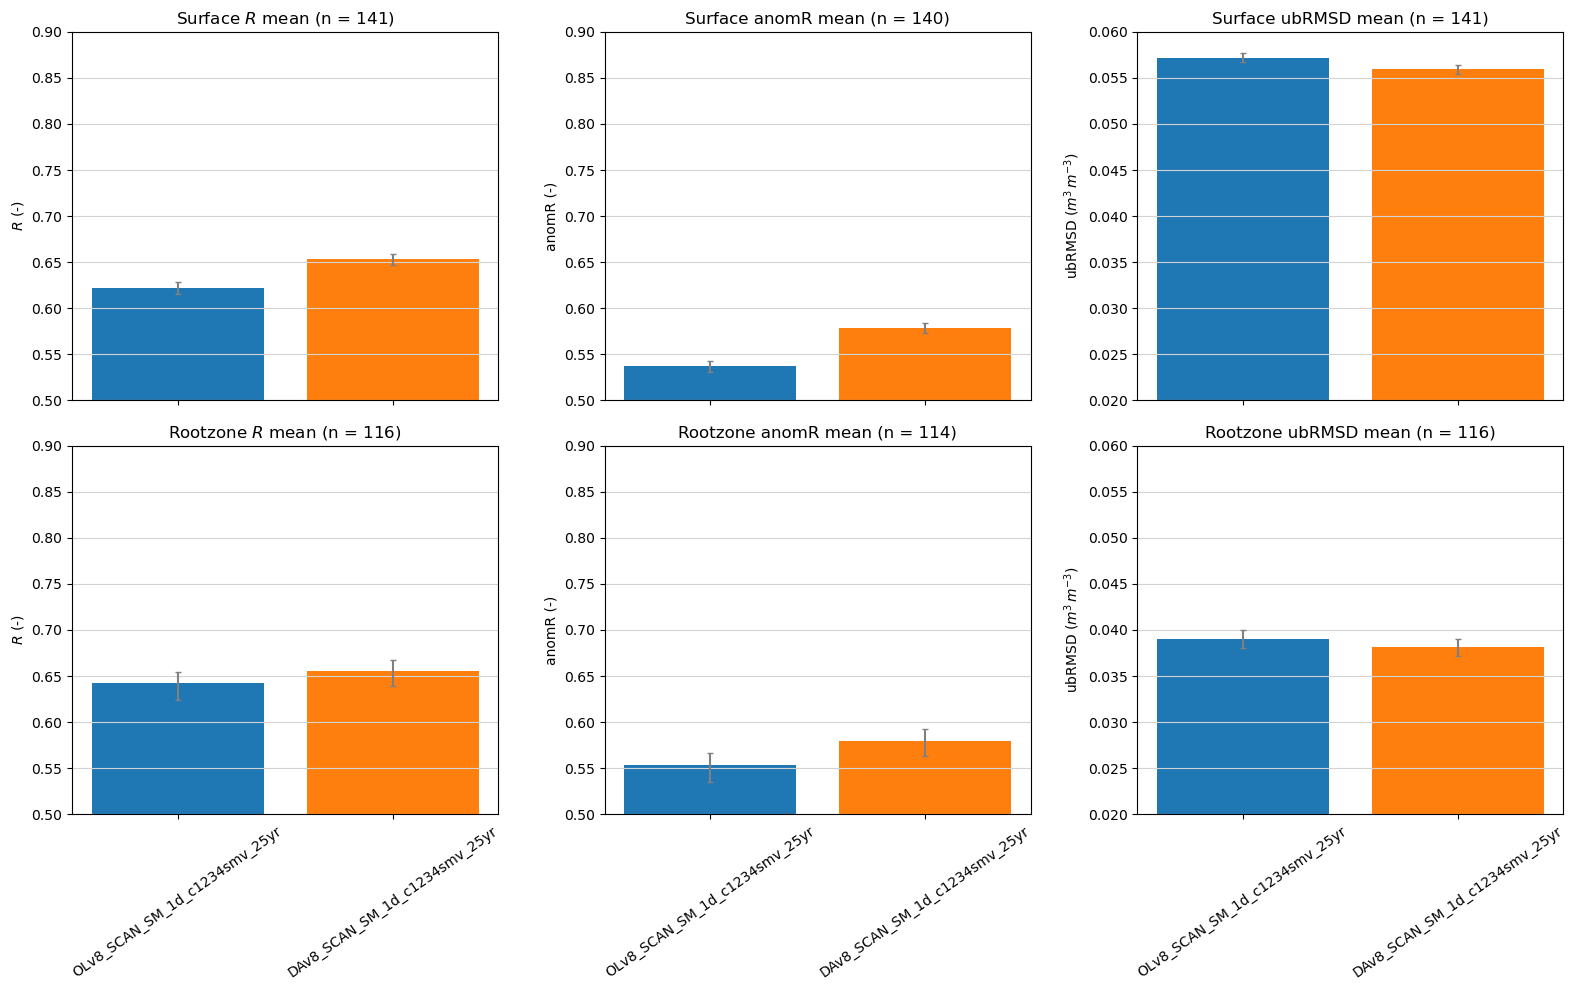

In [7]:
# ---- bar plots (surface vs root-zone) ----

num_expts = len(exp_keys)
ind = np.arange(num_expts)

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

axs[0, 0].bar(ind, R_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 0].errorbar(ind, R_mean[0, :num_expts], yerr=R_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[0, 0].set_ylabel(r'$R$ (-)')
axs[0, 0].set_ylim(0.5, 0.9)
axs[0, 0].grid(axis='y', color='lightgrey')
axs[0, 0].set_title(f'Surface $R$ mean (n = {int(num_sites_r[0, 0])})')
axs[0, 0].set_xticks(ind)
axs[0, 0].set_xticklabels('', fontsize=1)

if anomR is not None:
    axs[0, 1].bar(ind, anomR_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
    axs[0, 1].errorbar(ind, anomR_mean[0, :num_expts], yerr=anomR_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
    axs[0, 1].set_ylabel('anomR (-)')
    axs[0, 1].set_ylim(0.5, 0.9)
    axs[0, 1].grid(axis='y', color='lightgrey')
    axs[0, 1].set_title(f'Surface anomR mean (n = {int(num_sites_anomr[0, 0])})')
    axs[0, 1].set_xticks(ind)
    axs[0, 1].set_xticklabels('', fontsize=1)

axs[0, 2].bar(ind, ubRMSE_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 2].errorbar(ind, ubRMSE_mean[0, :num_expts], yerr=ubRMSE_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[0, 2].set_ylabel('ubRMSD ($m^3 \, m^{-3}$)')
axs[0, 2].set_ylim(0.02, 0.06)
axs[0, 2].grid(axis='y', color='lightgrey')
axs[0, 2].set_title(f'Surface ubRMSD mean (n = {int(num_sites_ubrmse[0, 0])})')
axs[0, 2].set_xticks(ind)
axs[0, 2].set_xticklabels('', fontsize=1)

axs[1, 0].bar(ind, R_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 0].errorbar(ind, R_mean[1, :num_expts], yerr=R_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[1, 0].set_ylabel(r'$R$ (-)')
axs[1, 0].set_ylim(0.5, 0.9)
axs[1, 0].grid(axis='y', color='lightgrey')
axs[1, 0].set_title(f'Rootzone $R$ mean (n = {int(num_sites_r[1, 0])})')
axs[1, 0].set_xticks(ind)
axs[1, 0].set_xticklabels(exp_labels[:num_expts], rotation=35)

if anomR is not None:
    axs[1, 1].bar(ind, anomR_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
    axs[1, 1].errorbar(ind, anomR_mean[1, :num_expts], yerr=anomR_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
    axs[1, 1].set_ylabel('anomR (-)')
    axs[1, 1].set_ylim(0.5, 0.9)
    axs[1, 1].grid(axis='y', color='lightgrey')
    axs[1, 1].set_title(f'Rootzone anomR mean (n = {int(num_sites_anomr[1, 0])})')
    axs[1, 1].set_xticks(ind)
    axs[1, 1].set_xticklabels(exp_labels[:num_expts], rotation=35)

axs[1, 2].bar(ind, ubRMSE_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 2].errorbar(ind, ubRMSE_mean[1, :num_expts], yerr=ubRMSE_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
axs[1, 2].set_ylabel('ubRMSD ($m^3 \, m^{-3}$)')
axs[1, 2].set_ylim(0.02, 0.06)
axs[1, 2].grid(axis='y', color='lightgrey')
axs[1, 2].set_title(f'Rootzone ubRMSD mean (n = {int(num_sites_ubrmse[1, 0])})')
axs[1, 2].set_xticks(ind)
axs[1, 2].set_xticklabels(exp_labels[:num_expts], rotation=35)

plt.tight_layout()
plt.show()


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_20266/3133721335.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)


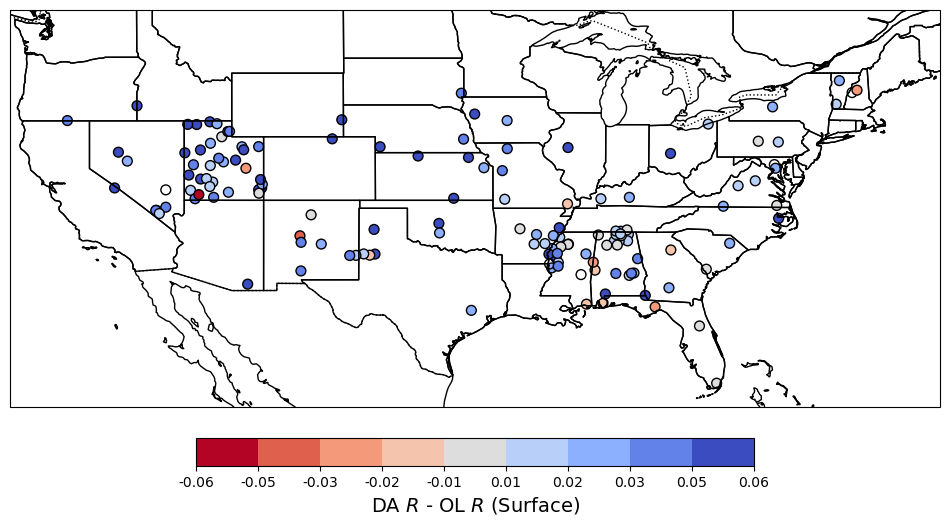

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_20266/3133721335.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)


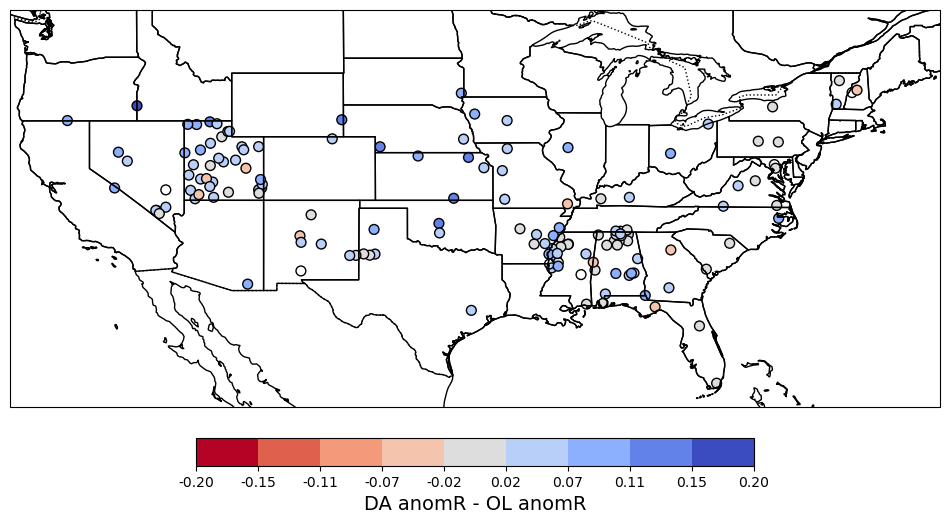

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_20266/3133721335.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm', len(levels) - 1)


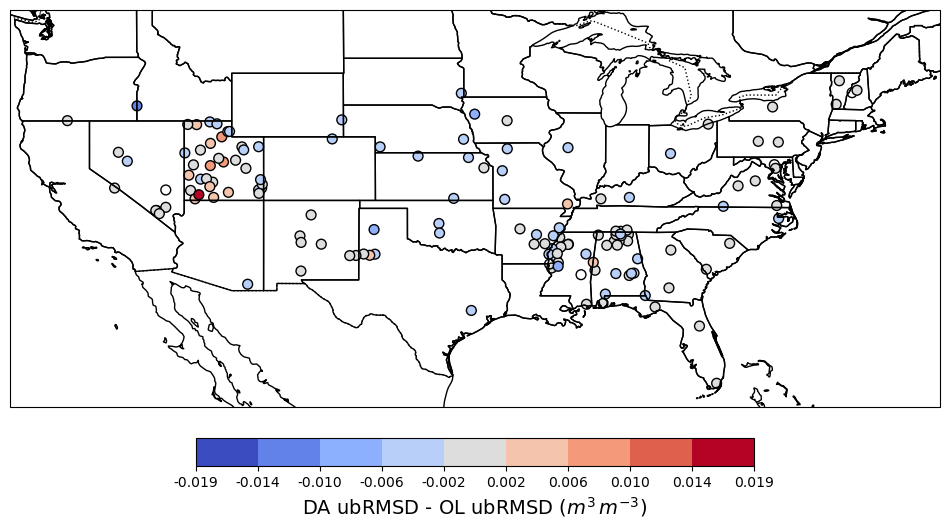

In [8]:
# ---- station maps: DA - OL (if 2 experiments and cartopy available) ----

if len(exp_keys) == 2 and meta and HAS_CARTOPY:
    lon = np.array(meta["lon"], dtype=float)
    lat = np.array(meta["lat"], dtype=float)

    # DA - OL for surface R
    R_diff = R[:, :, 1] - R[:, :, 0]
    levels = np.linspace(-0.06, 0.06, 10)
    cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)

    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

    sc = ax.scatter(lon, lat, c=R_diff[:, 0], cmap=cmap, s=50, edgecolor='k',
                    transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
    cbar.set_label(r'DA $R$ - OL $R$ (Surface)', fontsize=14)
    cbar.set_ticks(levels)
    cbar.ax.set_xticklabels([f"{lvl:.2f}" for lvl in levels])
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    plt.show()

    if anomR is not None:
        anomR_diff = anomR[:, :, 1] - anomR[:, :, 0]
        surf_diff = anomR_diff[:, 0]
        maxabs = np.nanmax(np.abs(surf_diff))
        levels = np.linspace(-maxabs, maxabs, 10) if maxabs and np.isfinite(maxabs) else np.linspace(-0.01, 0.01, 10)
        cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)

        fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, edgecolor='black')
        ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

        sc = ax.scatter(lon, lat, c=surf_diff, cmap=cmap, s=50, edgecolor='k',
                        transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

        cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
        cbar.set_label('DA anomR - OL anomR', fontsize=14)
        cbar.set_ticks(levels)
        cbar.ax.set_xticklabels([f"{lvl:.2f}" for lvl in levels])
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        plt.show()

    ubRMSE_diff = ubRMSE[:, :, 1] - ubRMSE[:, :, 0]
    surf_diff = ubRMSE_diff[:, 0]
    maxabs = np.nanmax(np.abs(surf_diff))
    levels = np.linspace(-maxabs, maxabs, 10) if maxabs and np.isfinite(maxabs) else np.linspace(-0.01, 0.01, 10)
    cmap = plt.cm.get_cmap('coolwarm', len(levels) - 1)

    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

    sc = ax.scatter(lon, lat, c=surf_diff, cmap=cmap, s=50, edgecolor='k',
                    transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
    cbar.set_label('DA ubRMSD - OL ubRMSD ($m^3\,m^{-3}$)', fontsize=14)
    cbar.set_ticks(levels)
    cbar.ax.set_xticklabels([f"{lvl:.3f}" for lvl in levels])
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    plt.show()
else:
    if not HAS_CARTOPY:
        print("Cartopy not available; skipping station maps.")
    elif len(exp_keys) != 2:
        print("Need exactly 2 experiments to plot DA - OL maps.")
    else:
        print("Station lat/lon not found in MAT file; skipping maps.")
